<a href="https://colab.research.google.com/github/Kaveeshamalindi/Spam-Classification/blob/main/Spam_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam Classification using NLP

## Step 1: Reading Data & Visualization

##Import Modules

In [58]:
import pandas as pd
import nltk #Natural Language Processing fundamentals

In [59]:
df = pd.read_csv("/content/sample_data/spam.csv",encoding="latin-1")

Pandas convert data into a tabular form

In [60]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [61]:
df.shape

(5572, 5)

**Remove the unwanted columns**

In [62]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

**Without inplace=True, it should be changed to**

`df1=df`

*After removing columns, the results as followings*

In [63]:
df.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [64]:
df.rename(columns={'v1':'class','v2':'sms'},inplace=True)
df.sample(5) ##To see the random data raws

,class,sms
4811,ham,"fyi I'm at usf now, swing by the room whenever"
3669,ham,Ok thanx... Take care then...
2679,spam,"New Tones This week include: 1)McFly-All Ab..,..."
3579,ham,Have a lovely night and when you wake up to se...
3969,ham,That's the trouble with classes that go well -...


**Gropu by based on classes (ham, spam)**

* **count**: Number of raws on each class

* **unique**: Number of unique entries

* Most duplicated ham sms is "Sorry, I'll call later." It is duplicated in 30 times.

* Most duplicated spam sms is "Please call our customer service representativ...." It is duplicated in 4 times

In [65]:
df.groupby("class").describe()

sms                                                               
      count unique                                                top freq
class                                                                     
ham    4825   4516                             Sorry, I'll call later   30
spam    747    653  Please call our customer service representativ...    4

**Remove the duplicates**

In [66]:
df = df.drop_duplicates(keep="first")

*See the result after removing the duplicates*

In [67]:
df.groupby("class").describe()

sms                                                               
      count unique                                                top freq
class                                                                     
ham    4516   4516                         Rofl. Its true to its name    1
spam    653    653  This is the 2nd time we have tried 2 contact u...    1

### Data Visualization

**Add new column, which called `length`**

*This column include the length of the sms (length of the String)*

In [68]:
df["length"] = df["sms"].apply(len)

In [69]:
df.head(2)

,class,sms,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29


hist refers to **Histrogram**

It shows the length column, `column="length"`

data in to graphs (ham & spam), `by="class"`

Length of 1-50, `bins=50`

**In the graph,**

*   High avg of ham length is less (1-200)
*   High avg of spam length is high (125-175)

Which means spam mails are so lengthy

array([<Axes: title={'center': 'ham'}>, <Axes: title={'center': 'spam'}>],
      dtype=object)

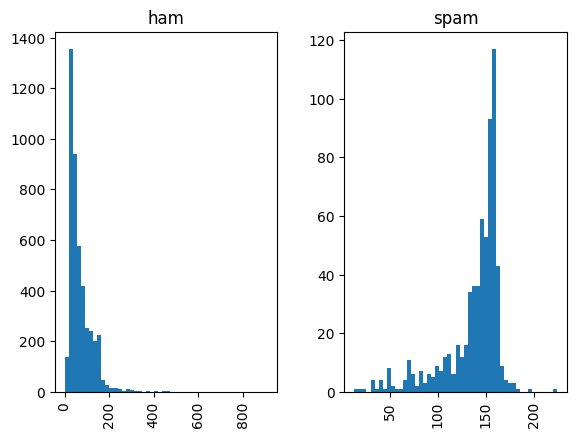

In [70]:
df.hist(column="length", by="class", bins=50)

## Step 2: Preprocessing

In [71]:
from nltk.stem.porter import PorterStemmer #Here Used the stemming instead of lemmatization

nltk.download('stopwords')
from nltk.corpus import stopwords

nltk.download('punkt_tab')
ps = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [72]:
df.head(5)

,class,sms,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


**Preprocessing Tasks**

* Lowercase
* Tokenization
* Removing Special characters
* Removing stopwords and punctuations
* Stemming

In [73]:
import string
def clean_text(text):
  text = text.lower() #Convert to lowercase
  text = nltk.word_tokenize(text) #Apply tokenization -> Break based on the white space

  y=[]
  for i in text:  #Check whether it only have alphabetical and numerical content
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    #Check wether it is stopword or not and wether it is punctuation or not
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y) #Joining all tokenes


In [74]:
df["sms_cleaned"] = df["sms"].apply(clean_text)

In [75]:
df.head(5)

,class,sms,length,sms_cleaned
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah think goe usf live around though


## Step 3: Feature Extraction

In [76]:
# using TI-TDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer


In [77]:
tf_vec = TfidfVectorizer(max_features=3000) #Define the size of the vocabulary
X = tf_vec.fit_transform(df["sms_cleaned"]).toarray()

Raws -> sms

Columns -> Tokens in the vocabulary: 3000

In [78]:
X.shape

(5169, 3000)

In [79]:
Y = df["class"].values

## Step 4: Learning

**Split the dataset into train and test data**

In [80]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

### Here use Algorithm called **naive_bayes**, it is a ML algorithm

In [81]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

### Measure Accuracy

In [82]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test) #y predict by model
print(accuracy_score(y_test,y_pred))

0.9709864603481625


Download the pickle file